# Метод k ближайших соседей (kNN)

В этом ноутбуке разберём **метод k ближайших соседей (k-Nearest Neighbors, kNN)** для классификации.

**Цели ноутбука:**
- Понять геометрическую идею kNN.
- Обсудить выбор расстояния и гиперпараметров.
- Реализовать **kNN с нуля** на `numpy`.
- Сравнить с `KNeighborsClassifier` из `sklearn`, в том числе визуально по границе решений.

---

**Содержание:** Теория → Данные → Реализация с нуля → Сравнение с sklearn → Визуализация границ.


## Идея метода k ближайших соседей

Идея kNN очень проста:
- мы **запоминаем всю обучающую выборку**;
- чтобы классифицировать новый объект $x$, находим его $k$ ближайших соседей в обучающей выборке по некоторому расстоянию (обычно евклидову);
- смотрим, какие классы среди этих соседей, и отдаём, например, **большинство голосов**.

Формально, пусть $N_k(x)$ — множество индексов $k$ ближайших соседей объекта $x$. Тогда предсказание для классификации можно записать как
$$
\hat{y}(x) = \arg\max_c \sum_{i \in N_k(x)} [y_i = c],
$$
где $[y_i = c]$ — **индикаторная функция**: она равна 1, если объект $i$ действительно имеет метку класса $c$, и 0, если $y_i \neq c$. Таким образом сумма по всем соседям просто считает, сколько из них принадлежат классу $c$. 

Метод kNN:
- **не строит явную модель** (это *lazy learning*),
- но часто даёт неплохие результаты, особенно когда у нас достаточно объектов и разумная метрика расстояния.


## Выбор расстояния и гиперпараметров

Основные решения при использовании kNN:

- **Число соседей $k$**:
  - маленькое $k$ (например, 1) даёт низкое смещение, но высокую дисперсию (чувствительность к шуму);
  - большое $k$ сглаживает решение, но может проигрывать по локальной точности.
- **Метрика расстояния**:
  - чаще всего — **евклидово расстояние** (L2),
  - иногда манхэттенское (L1) или другие.
- **Взвешивание соседей**:
  - можно голосовать поровну,
  - можно взвешивать по расстоянию (чем ближе, тем больший вес).

Важно помнить, что kNN чувствителен к **масштабам признаков**, поэтому обычно перед ним применяют стандартизацию.


## Пример на синтетических данных

Сгенерируем двумерные данные с нелинейно разделимыми классами (например, `make_moons`), чтобы наглядно увидеть границы решений для разных $k$.


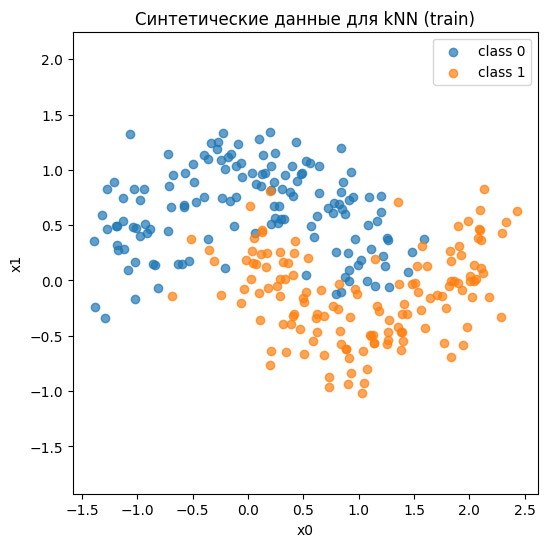

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

X, y = make_moons(n_samples=400, noise=0.25, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Для kNN полезно отмасштабировать признаки
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

plt.figure(figsize=(6, 6))
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], color="tab:blue", alpha=0.7, label="class 0")
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], color="tab:orange", alpha=0.7, label="class 1")
plt.title("Синтетические данные для kNN (train)")
plt.xlabel("x0")
plt.ylabel("x1")
plt.legend()
plt.axis("equal")
plt.show()


## Реализация kNN с нуля

Сделаем простую реализацию kNN-классификатора:
- на шаге `fit` просто запомним обучающие объекты и их метки;
- на шаге `predict` для каждого нового объекта:
  - посчитаем расстояния до всех обучающих объектов,
  - найдём индексы $k$ ближайших,
  - отдадим класс большинства среди этих соседей.

Для расстояния используем стандартную **евклидову норму (L2)**.


In [2]:
from collections import Counter

class KNNScratch:
    def __init__(self, n_neighbors: int = 5):
        self.n_neighbors = n_neighbors
        self.X_train_ = None
        self.y_train_ = None

    def fit(self, X: np.ndarray, y: np.ndarray):
        self.X_train_ = np.asarray(X)
        self.y_train_ = np.asarray(y)
        return self

    def _predict_one(self, x: np.ndarray) -> int:
        # Евклидовы расстояния до всех обучающих объектов
        distances = np.linalg.norm(self.X_train_ - x, axis=1)
        # Индексы k ближайших
        idx = np.argsort(distances)[: self.n_neighbors]
        nearest_labels = self.y_train_[idx]
        # Голосование по большинству
        counter = Counter(nearest_labels)
        # most_common возвращает список (label, count), берём первый
        return counter.most_common(1)[0][0]

    def predict(self, X: np.ndarray) -> np.ndarray:
        X = np.asarray(X)
        return np.array([self._predict_one(x) for x in X])


knn_scratch = KNNScratch(n_neighbors=5)
knn_scratch.fit(X_train_scaled, y_train)

y_pred_train = knn_scratch.predict(X_train_scaled)
y_pred_test = knn_scratch.predict(X_test_scaled)

train_acc = (y_pred_train == y_train).mean()
test_acc = (y_pred_test == y_test).mean()

print(f"kNN scratch (k=5) train accuracy: {train_acc:.3f}")
print(f"kNN scratch (k=5) test  accuracy: {test_acc:.3f}")


kNN scratch (k=5) train accuracy: 0.936
kNN scratch (k=5) test  accuracy: 0.942


## Визуализация границы решений (scratch)

Построим границу решений для самописного kNN в 2D.


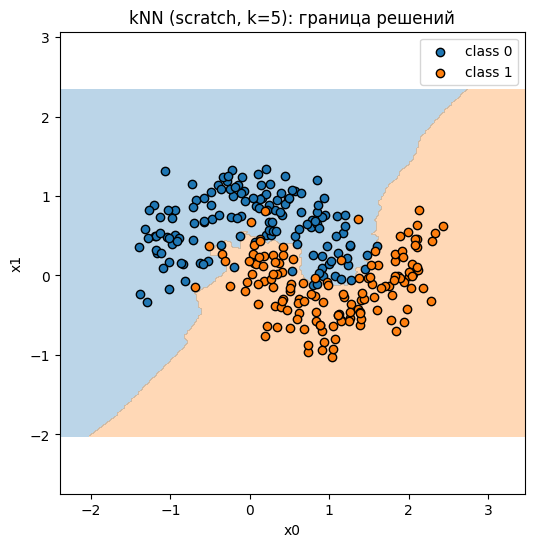

In [3]:
# Сетка в исходном пространстве
x_min, x_max = X[:, 0].min() - 1.0, X[:, 0].max() + 1.0
y_min, y_max = X[:, 1].min() - 1.0, X[:, 1].max() + 1.0
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200),
)
grid = np.c_[xx.ravel(), yy.ravel()]
grid_scaled = scaler.transform(grid)
zz = knn_scratch.predict(grid_scaled).reshape(xx.shape)

plt.figure(figsize=(6, 6))
plt.contourf(xx, yy, zz, alpha=0.3, levels=[-0.5, 0.5, 1.5], colors=["tab:blue", "tab:orange"])
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], color="tab:blue", edgecolor="k", label="class 0")
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], color="tab:orange", edgecolor="k", label="class 1")
plt.title("kNN (scratch, k=5): граница решений")
plt.xlabel("x0")
plt.ylabel("x1")
plt.legend()
plt.axis("equal")
plt.show()


## `KNeighborsClassifier` из `sklearn`

Теперь воспользуемся `KNeighborsClassifier` из `scikit-learn` и сравним результаты.


kNN sklearn (k=5) train accuracy: 0.936
kNN sklearn (k=5) test  accuracy: 0.942


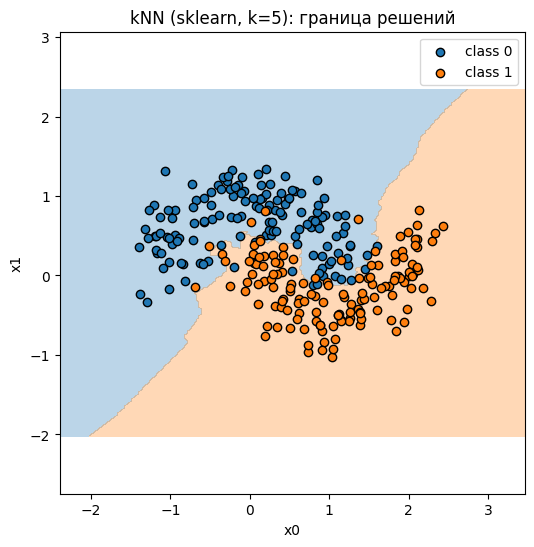

In [4]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=5, metric="minkowski", p=2)
knn.fit(X_train_scaled, y_train)

y_pred_train_sk = knn.predict(X_train_scaled)
y_pred_test_sk = knn.predict(X_test_scaled)

train_acc_sk = accuracy_score(y_train, y_pred_train_sk)
test_acc_sk = accuracy_score(y_test, y_pred_test_sk)

print(f"kNN sklearn (k=5) train accuracy: {train_acc_sk:.3f}")
print(f"kNN sklearn (k=5) test  accuracy: {test_acc_sk:.3f}")

# Визуализируем границу решений sklearn-модели
zz_sk = knn.predict(grid_scaled).reshape(xx.shape)

plt.figure(figsize=(6, 6))
plt.contourf(xx, yy, zz_sk, alpha=0.3, levels=[-0.5, 0.5, 1.5], colors=["tab:blue", "tab:orange"])
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], color="tab:blue", edgecolor="k", label="class 0")
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], color="tab:orange", edgecolor="k", label="class 1")
plt.title("kNN (sklearn, k=5): граница решений")
plt.xlabel("x0")
plt.ylabel("x1")
plt.legend()
plt.axis("equal")
plt.show()


## Выводы

- **kNN** — метод без явной модели: классификация по голосованию k ближайших соседей; важны выбор k, метрика и масштабирование признаков.
- Реализация с нуля на numpy помогает понять механику; на практике удобно использовать `sklearn.KNeighborsClassifier` с настройкой метрик и весов.
- Визуализация границ решений полезна для интерпретации и подбора гиперпараметров.
